# 6.) 빠진 조각 : 비선형성(Non-linearity) <br>
모델이 선형 레이어 덕분에 직선을 그릴 수 있다는 것을 확인했음
- 모델이 직선이 아닌 비선형을 그릴 수 있도록 한다면?


# 6.1 ) 비선형 데이터 다시 만들기 (빨간색 & 파란색 원)


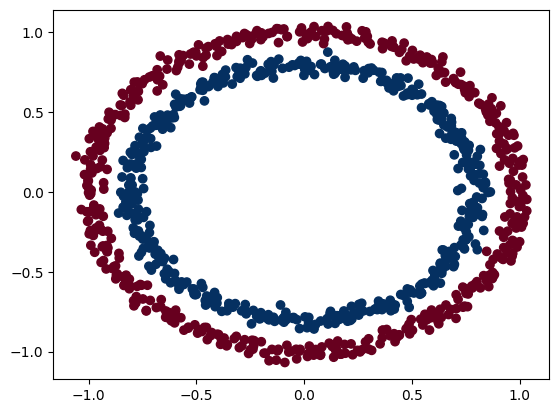

In [76]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples= 1000,
                    noise=0.03,
                    random_state=42,
)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu);

In [77]:
# 데이터를 텐서로 변환하고, 훈련/테스트 세트로 나눔
import torch
from sklearn.model_selection import train_test_split

# Numpy 배열을 pytorch 텐서로 변환
X = torch.from_numpy(X).type(torch.float)   # Numpy 배열 X를 pytorch 텐서로 변환
y = torch.from_numpy(y).type(torch.float)   # 정답 라벨 y도 pytorch 텐서로 변환

# 데이터를 훈련용/테스트용으로 분할
X_train, X_test, y_train, y_test = train_test_split(X,  # train_test_split(...) : 데이터를 무작위로 섞은 뒤 분할
                                                    y,  
                                                    test_size=0.2,  # train_test_split(...) : 데이터를 무작위로 섞은 뒤 분할
                                                    random_state=42
)


X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

# 6.2 ) 비선형성을 가진 모델
- 비선형 활성화 함수 중 가장 흔하게 쓰이고 성능 좋은 것 -> ReLU (Rectified Linear Unit, torch.nn.ReLU())
- 순전파(forward pass)에서 은닉층 사이에 RELU를 넣어 신경망의 변화 살피기

In [78]:
# 비선형 활성화 함수를 포함한 모델을 생성
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"

class CircleModelV2(nn.Module):     # nn.Module을 상속받는 새 모델 클래스 정의
    def __init__(self):
        super().__init__()  #nn.Module의 내부 초기화
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)    # 출력 레이어- 이진 분류용 logit 1개 출력
        self.relu = nn.ReLU()   # <- ReLU 활성화 함수 정의
        # sigmoid를 모델 안에 넣을 수 있음. 이러면 예측 단계에서 따로 sigmoid를 쓸 필요 없음
        # 현재는 BCEWithLogitsLoss 사용 예정이라 sigmoid가 손실 함수 안에 있으니 실제로 사용 x
    
    def forward(self, x):
        #레이어 사이사이에 ReLU 활성화 함수 끼워 넣음
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))    # 이렇게 하면 곡선 결정 경계 가능                                     
model_3 = CircleModelV2().to(device)    #CircleModelV2 인스턴스 생성
print(model_3)

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


- 신경망을 구성할 때 비선형 활성화 함수는 어디에 두어야 할까?
-일반적인 경험 법칙(rule of thumb) : 은닉층 사잉에 넣고 출력층 바로 뒤에도 넣는 것 <br>
--> 절대적인 규칙 X
- 모델이 준비되었으니 이진 분류용 손실 함수(binary classification loss function)와 optimizer 만들기


In [79]:
# 손실과 opimizer 세팅
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

In [80]:
# 분류 문제에서 정확도 계산하는 함수 정의
def accuracy_fn(y_true, y_pred):        # y_true : 실제 정답(label), y_pred : 모델이 예측한 값(prediction)
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq(y_true, y_pred) : 두 텐서의 각 원소를 비교해서 같은 위치는 True, 다른 위치는 False로 반환
    acc = (correct/len(y_pred)) * 100       # len(y_pred): 전체 예측 개수 # correct / len(y_pred) : 전체 중에서 맞춘 비율
    return acc

# 6.3 ) 비선형의 모델 학습하기

- 학습 / 테스트 루프 생성

In [81]:
torch.manual_seed(42)
epochs = 1000

# 데이터들 device 이동
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    # 1. forward pass
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) 
    
    # 2. 손실과 정확도 계산
    loss = loss_fn(y_logits, y_train) 
    acc = accuracy_fn(y_true=y_train,
                       y_pred=y_pred)
    
    # 3. optimizer 가중치 초기화
    optimizer.zero_grad()
    
    # 4. Loss backward
    loss.backward()
    
    # 5. optimizer step
    optimizer.step()
    
    ### testing
    model_3.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. 정확도와 손실 계산
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred= test_pred)
        
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")
        

Epoch: 0 | Loss: 0.69295, Accuracy: 50.00% | Test Loss: 0.69319, Test Accuracy: 50.00%
Epoch: 100 | Loss: 0.69115, Accuracy: 52.88% | Test Loss: 0.69102, Test Accuracy: 52.50%
Epoch: 200 | Loss: 0.68977, Accuracy: 53.37% | Test Loss: 0.68940, Test Accuracy: 55.00%
Epoch: 300 | Loss: 0.68795, Accuracy: 53.00% | Test Loss: 0.68723, Test Accuracy: 56.00%
Epoch: 400 | Loss: 0.68517, Accuracy: 52.75% | Test Loss: 0.68411, Test Accuracy: 56.50%
Epoch: 500 | Loss: 0.68102, Accuracy: 52.75% | Test Loss: 0.67941, Test Accuracy: 56.50%
Epoch: 600 | Loss: 0.67515, Accuracy: 54.50% | Test Loss: 0.67285, Test Accuracy: 56.00%
Epoch: 700 | Loss: 0.66659, Accuracy: 58.38% | Test Loss: 0.66322, Test Accuracy: 59.00%
Epoch: 800 | Loss: 0.65160, Accuracy: 64.00% | Test Loss: 0.64757, Test Accuracy: 67.50%
Epoch: 900 | Loss: 0.62362, Accuracy: 74.00% | Test Loss: 0.62145, Test Accuracy: 79.00%


# 6.4 ) 비선형 활성화 함수로 학습된 모델 평가

- 비선형 활성화 함수로 학습된 모델의 예측 결과 확인 <br>
비선형성을 추가한 뒤 모델의 예측이 어떻게 달라졌는지 확인


In [82]:
# 예측 수행
model_3.eval()
with torch.inference_mode():        # 추론(inference) 모드
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
    # model_3(X_test):테스트 데이터 입력.출력은 logits. torch.sigmoid():logits->확률(0~1) torch.round():확률->예측라벨  squeeze():불필요한 차원 제거 
y_preds[:10], y[:10]    # 예측값을 살제 라벨과 같은 형식으로 맞추고 싶음
    

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

In [83]:
# model_1 
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        # 첫 번째 선형 레이어 - 입력 특성 수: 원 데이터가(x좌표, y좌표)같은 2차원 특징이라서 2, 출력 유닛 수 : 은닉 유닛 10개로 확장(=너비 늘림)
        self.layer_1 = nn.Linear(in_features=2, out_features=10) 
        self.layer_2 = nn.Linear(in_features=10, out_features=10)   # 추가 레이어 (깊이 늘림)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
    
    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x))) # sigmoid 적용 전이라 최종 반환값은 logits
    
model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

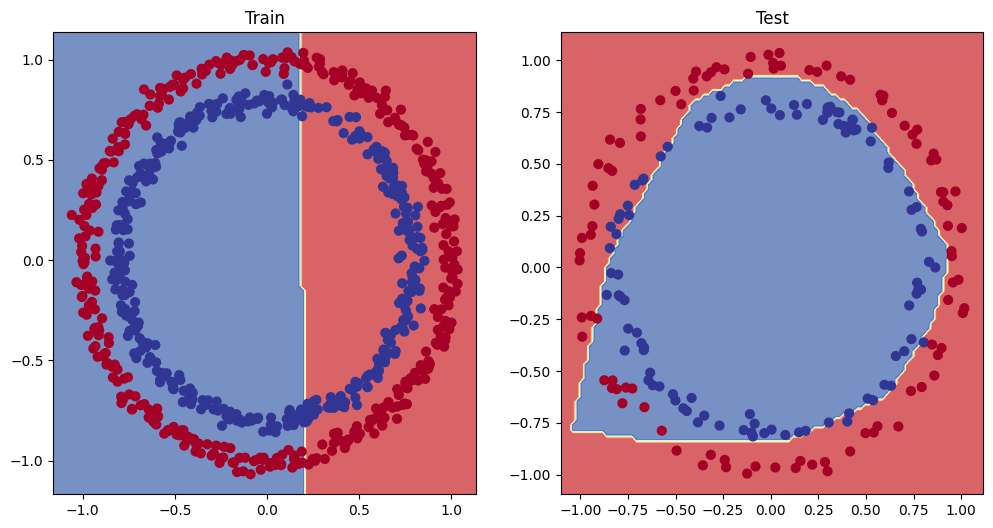

In [84]:
import requests
from pathlib import Path 
from helper_functions import plot_predictions, plot_decision_boundary
# 훈련/테스트 데이터에 대한 결정 경계(decision boundary)를 그림
plt.figure(figsize=(12,6))  # 하나의 큰 그림 생성. 가로 12, 세로 6
plt.subplot(1, 2, 1)    # 1행 2열 중 첫 번째 위치. 즉, 왼쪽 그래프
plt.title("Train")  # 왼쪽 그래프 제목을 "Train"
plot_decision_boundary(model_1, X_train, y_train)   # model_1의 결정 경계 그림. model_1은 ReLU같은 비선형 활성화 함수 x.
plt.subplot(1, 2, 2)   # 1행 2열 중 두 번째 위치. 즉, 오른쪽 그래프
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # model_3의 결정 경계 그림

-> 좋아! 이전보다 훨씬 나아짐
# 7)  비선형 활성화 함수 재현

- 실제 마주치는 데이터들은 비선형 또는 선형+비선형

- 비선형 활성화 함수의 모양 알아보기



In [85]:
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

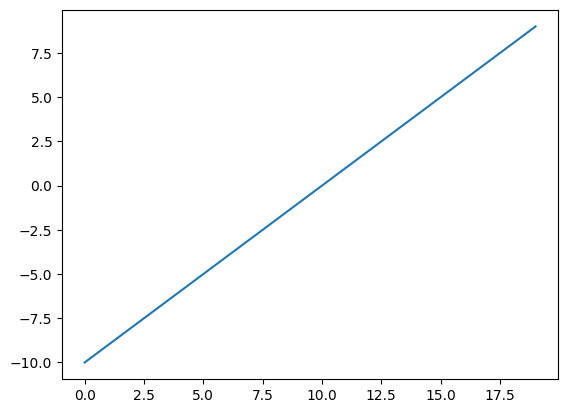

In [86]:
plt.plot(A);

- ReLU 활성화 함수가 직선에 어떤 영향을 주는지 확인
- PyTorch에서 제공하는 ReLU(torch.nn.ReLU)를 쓰는 대신, 우리가 직접 ReLU를 만들어서 확인해볼 예정 <br>
-ReLU 함수는 음수 값을 모두 0으로 바꾸고, 양수 값은 그대로 유지

In [87]:
# ReLU 함수 직접 정의
def relu(x):
    return torch.maximum(torch.tensor(0), x)    # torch.maximum(a, b): 두 값 중 큰 값 선택

# 장난감 데이터 A를 ReLU 함수에 통과시킴
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

-> ReLU 함수가 잘 작동하는 것 같음. 모든 음수 값이 0이 되었음 <br>
- 그래프 그려보기

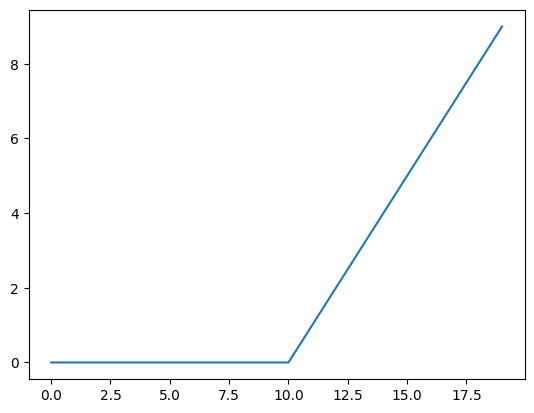

In [88]:
# ReLU가 적용된 값들을 그래프로 시각화
plt.plot(relu(A))

-> 위키피디아에 나와 있는 ReLU 함수 그래프모양과 같음

- sigmoid 함수 <br>
: 입력값을 0. 1 사이의 실수로 변환해 확률로 해석하게 하는 S자 형태(sigmoid curve) 의 비선형 활성화 함수

In [89]:
# sigmoid 함수 정의
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

sigmoid(A)


tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

* torch.exp(-x) → 𝑒** (−x)

- 우리는 모델에게 패턴을 스스로 찾아낼 수 있는 도구를 줌 <br>
-> 그 도구가 선형 함수와 비선형 함수

- 신경망은 선형 + 비선형 함수라는 도구를 이용해 패턴을 스스로 찾아내는 구조

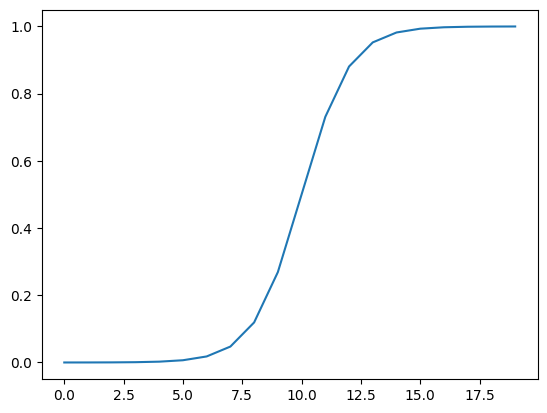

In [90]:
plt.plot(sigmoid(A))

# 8 ) 다중 클래스 Pytorch 모델 만들며 모든 것 연결하기

- 이진 분류 : 두 가지 중 하나를 분류
- 다중 클래스 분류 (multi-class classification) : 두 개보다 많은 선택지 중 하나를 분류하는 문제



Scikit-Learn의 make_blobs() 메서드 : centers 파라미터를 통해 원하는 만큼의 클래스 생성해줌

1. make_blobs()로 다중 클래스 데이터 생성
2. 데이터를 텐서로 변환 ( make_blobs()의 기본 출력은 NumPy 배열)
3. train_test_split()으로 학습/데이터 분리
4. 데이터 시각화

tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


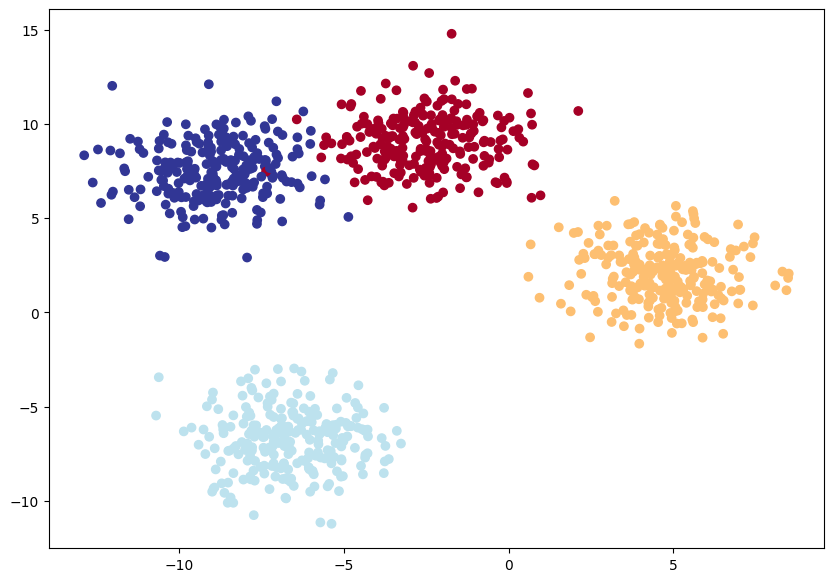

In [91]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs     # make_blobs : 인위적인 군집 데이터 생성
from sklearn.model_selection import train_test_split

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. 다중 클래스 데이터 생성
X_blob, y_blob = make_blobs(n_samples=1000,
    n_features=NUM_FEATURES, # X features
    centers=NUM_CLASSES,   # y lables
    cluster_std=1.5, # 각 클래스가 퍼지는 정도 (값 ↑ → 클래스 간 겹침 ↑)
    random_state=RANDOM_SEED
)
# 2. 텐서로 데이터 변경
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

# 3. train과 test 세트로 분할
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(
    X_blob,
    y_blob,
    test_size=0.2,  # 전체의 20%를 테스트 데이터로 사용
    random_state=RANDOM_SEED    # 분할 결과 고정
)
# 4. plot data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu); # 2차원 좌표로 데이터 시각화. 색상은 클래스(y)에 따라 다르게 표시

# 8.2 ) 다중 클래스 분류 모델 만들기

- 다중 클래스 데이터를 처리할 수 있는 모델 만들기 <br>
-nn.Module 상속받는 클래스 만들고 다음 세가지 하이퍼 파라미터 받기 <br>
-input_features(입력 특성 개수), output_features(출력 특성 개수= 클래스 수), hidden_units(은닉층 뉴런 개수) <br>
-디바이스 독립 코드도 함께 설정 <br>

In [92]:
device = "cuda" if torch. cuda.is_available() else "cpu"
device

'cuda'

In [93]:
from torch import nn

#Build model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),       # 입력층 -> 은닉층
            nn.Linear(in_features=hidden_units, out_features=hidden_units),     # 은닉층 -> 은닉층
            nn.Linear(in_features=hidden_units, out_features=output_features),  # 은닉층 -> 출력층. 출력 노드 수 = 클래스 수 (4)
        )
    def forward(self, x):
        return self.linear_layer_stack(x)   # 입력 x를 레이러 스택에 통과시켜 출력. 출력값 = logits
    
# BlobModel 객체 생성 후 사용 중이 디바이스로 이동시킴
model_4 = BlobModel(
    input_features = NUM_FEATURES,
    output_features=NUM_CLASSES,
    hidden_units=8
).to(device)

model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

# 8.3  )  손실 함수 & 옵티마이저
- nn.CrossEntropyLoss()를 손실 함수로 사용 & 옵티마이저는 SGD, 학습률은 0.1

In [94]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(), 
                           lr=0.1)  # lr 수정해서 모델 수행의 변화 확인해보기

# 8.4 ) 예측 확률 구하기

In [95]:
model_4(X_blob_train.to(device))[:5]

tensor([[-1.0821,  0.2580, -0.6953,  0.7268],
        [-0.4015,  2.0296,  2.3008,  1.7942],
        [ 1.3277, -0.3837,  0.2508, -1.6811],
        [ 0.7637,  0.1111,  0.5110, -0.8092],
        [-0.1890,  1.7277,  2.0414,  1.3623]], device='cuda:0',
       grad_fn=<SliceBackward0>)

In [96]:
# 한 샘플의 출력 크기 확인
model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES

(torch.Size([4]), 4)

-> 클래수 수(4)와 일치

- 이 모델의 원시 출력값 : logits
- logits -> 확률 -> 예측 라벨로 변경해보기. softmax 활용



In [97]:
y_logits = model_4(X_blob_test.to(device))  # 테스트 데이터에 대한 logits 계산
y_pred_probs = torch.softmax(y_logits, dim=1)   # logits -> 클래스별 확률, 각 샘플의 확률 합 = 1
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-1.0943,  0.4862, -0.3858,  0.9402],
        [ 0.4370,  2.1385,  3.0942,  1.2537],
        [ 0.9735, -0.4166, -0.0660, -1.4409],
        [-0.7948,  0.0490, -0.7677,  0.3211],
        [-0.7592,  1.8848,  1.8249,  1.9368]], device='cuda:0',
       grad_fn=<SliceBackward0>)
tensor([[0.0644, 0.3126, 0.1307, 0.4923],
        [0.0435, 0.2383, 0.6198, 0.0984],
        [0.5910, 0.1472, 0.2090, 0.0528],
        [0.1351, 0.3140, 0.1388, 0.4122],
        [0.0232, 0.3261, 0.3072, 0.3435]], device='cuda:0',
       grad_fn=<SliceBackward0>)


- 아직 소프트맥스 함수의 출력값들이 뒤죽박죽된 숫자처럼 보일 수 있어요 <br>
-실제로 그렇기도 해요. 왜냐하면 모델이 아직 학습되지 않았고, 무작위 패턴으로 예측하고 있기 때문

- logits를 softmax 함수에 통과시키고 나면, 각 개별 샘플의 값들을 모두 더했을 때 1이 나옴. (부동소수점 오차 때문에 1에 아주 가깝게 나오기도 함)

In [98]:
# softmax 활성화 함수의 출력 중 첫 번째 샘플의 값들 모두 더해보기
torch.sum(y_pred_probs[0])

tensor(1., device='cuda:0', grad_fn=<SumBackward0>)

-> softmax를 거친 하나의 샙플은 확률이기 때문에 항상 1

- 이 예측 확률들-모델이 특정 입력 데이터(X)가 각 클래스에 얼마나 속한다고 생각하는지를 나타냄
- y_preds_probs <br>
클래스 개수만큼 값이 있고, 그 중 가장 큰 값의 인덱스가 모델이 가장 가능성이 높다고 판단한 클래스
- 가장 큰 값의 인덱스 -> torch.argmax() 확인

In [99]:
# 모델이 index 0 샘플에 가장 맞다고 생각한 클래스는 무엇?
print(y_pred_probs[0])      # 0번 샘플에 대한 각 클래스별 예측 확률 출력
print(torch.argmax(y_pred_probs))   # 가장 큰 확률값을 가진 클래스의 인덱스 출력

tensor([0.0644, 0.3126, 0.1307, 0.4923], device='cuda:0',
       grad_fn=<SelectBackward0>)
tensor(542, device='cuda:0')


-> 아직 모델이 제대로 학습되지 않았기 때문에 완전 랜덤 추측. 클래스가 4개라 맞을 확률은 25%

*핵심 개념 정리
- 모델의 원시 출력값 -> logits
- 멀티클래스 분류에서 logits->확률은 softmax, 확률->클래스 번호는 argmax
- 가장 확률이 높은 값의 인덱스가 예측 클래스


# 8.5 ) 멀티클래스 모델 학습 루프 만들기
- 모델을 학습/평가 하는 훈련 & 테스트 루프 만들기

In [100]:
torch.manual_seed(42)   #난수 고정
epochs=100      #전체 데이터 100번 반복 학습

# 데이터 전체를 GPU(cuda) 또는 CPU로 이동
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    ### 모델을 훈련모드로 설정
    model_4.train() 
    
    # 1. Forward pass
    y_logits = model_4(X_blob_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)       #logits → softmax → 확률 , 확률 → argmax → 예측 클래스 라벨
    # 2. 손실 & 정확도 계산 
    loss = loss_fn(y_logits, y_blob_train)  #모델이 낸 원시 출력값(logits) y_logits랑 정답 라벨 y_blob_train을 비교 -> 얼마나 틀렸는지(손실, loss) 를 계산
    acc = accuracy_fn(y_true=y_blob_train,  # y_true에는 y_blob_train을 넣고, y_pred에는 y_pred를 넣어서 계산
                      y_pred=y_pred)
    
    # 3. 이전 epoch의 gradient 초기화
    optimizer.zero_grad()
    
    # 4. 역전파로 gradient 계산
    loss.backward()
    
    # 5. 가중치 업데이트
    optimizer.step()
    
    
    ### 모델을 평가 모드로 설정
    model_4.eval()
    with torch.inference_mode():    # gradient 계산 비활성화 -> 속도 & 메모리 절약
        # 1. forward pass
        test_logits = model_4(X_blob_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        
        # 2. 테스트 손실과 정확도 계산
        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true=y_blob_test, y_pred=test_pred)
        
        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")
    

Epoch: 0 | Loss: 2.13841, Acc: 1.75% | Test Loss: 1.09025, Test Acc: 48.00%
Epoch: 10 | Loss: 0.37436, Acc: 89.00% | Test Loss: 0.32992, Test Acc: 80.50%
Epoch: 20 | Loss: 0.12644, Acc: 98.75% | Test Loss: 0.11471, Test Acc: 99.00%
Epoch: 30 | Loss: 0.07718, Acc: 99.00% | Test Loss: 0.07082, Test Acc: 99.50%
Epoch: 40 | Loss: 0.05883, Acc: 99.00% | Test Loss: 0.05214, Test Acc: 99.50%
Epoch: 50 | Loss: 0.04937, Acc: 99.00% | Test Loss: 0.04224, Test Acc: 99.50%
Epoch: 60 | Loss: 0.04370, Acc: 99.00% | Test Loss: 0.03618, Test Acc: 99.50%
Epoch: 70 | Loss: 0.03997, Acc: 99.00% | Test Loss: 0.03213, Test Acc: 99.50%
Epoch: 80 | Loss: 0.03735, Acc: 99.00% | Test Loss: 0.02924, Test Acc: 99.50%
Epoch: 90 | Loss: 0.03542, Acc: 99.00% | Test Loss: 0.02708, Test Acc: 99.50%


# 8.6 ) 멀티클래스 모델로 예측 만들고 평가

In [101]:
# 예측 만들기
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)
    
y_logits[:10]

tensor([[  3.6612,   8.8301, -12.3560,  -8.8035],
        [  3.9148, -10.4133,   2.1763,   9.3920],
        [ -8.0021, -10.9729,  19.5329,  11.3022],
        [  0.7978,   6.5658,  -6.5374,  -6.3274],
        [  7.6894,   2.5730, -13.2343,  -3.3441],
        [  4.4883, -12.9441,   3.3203,  11.7224],
        [ -8.3631,  -8.2473,  17.9361,   8.7627],
        [  6.4801,  -0.8490,  -8.8686,   0.0367],
        [ -8.1244, -15.4799,  23.1944,  15.5848],
        [  6.7812,   0.4078, -10.2688,  -1.1884]], device='cuda:0')

-> 우리 모델 예측값이 아직 logit 형태
이 값들을 평가하려면 정답 라벨(y_blob_test)과 같은 정수 형태여야 함

1. 모델이 출력한 logits를 먼저 예측 확률로 바꿈 (torch.softmax() 사용) 
2. 각 샘플마다 가장 큰 확률을 가진 값의 인덱스 선택해 예측 라벨로 변환(argumax() 사용)

In [104]:
# 예측된 logits를 예측 확률로 변환
y_pred_probs = torch.softmax(y_logits, dim=1)   # logits 각 행(샘플 하나)마다 softmax 적용. 클래스별 값이 확률로 바뀜

# 예측 확률을 예측 라벨로 변환
y_preds = y_pred_probs.argmax(dim=1)

# 앞 10개만 예측값과 정답 비교
print(f"Predictions: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_blob_test, y_pred=y_preds)}%")

Predictions: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Labels: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Test accuracy: 99.5%


모델의 예측값이 테스트 라벨과 같은 형태가 됨
- plot_decision_boundary()를 사용해서 결과를 시각화

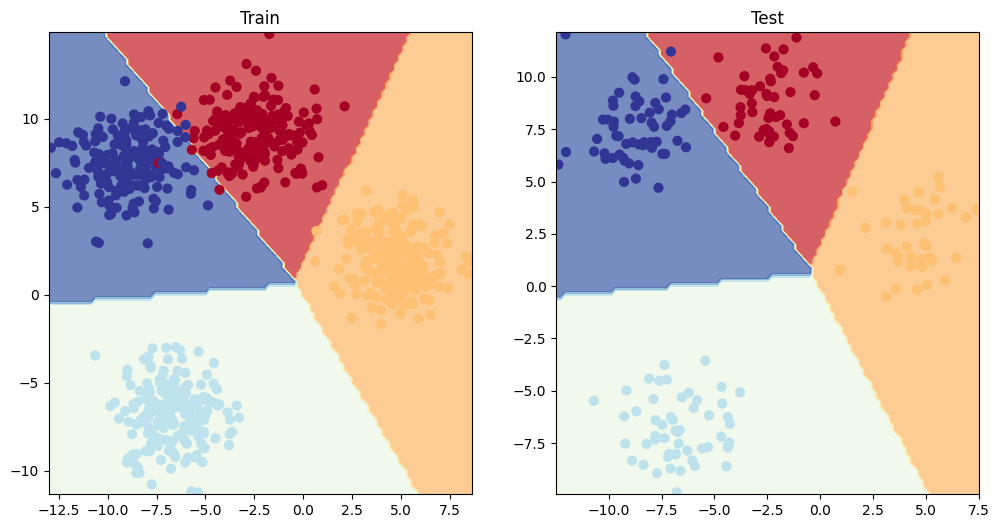

In [102]:
plt.figure(figsize=(12, 6)) # 그래프 크기 설정
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)
